In [33]:
import pandas as pd

file_path = "/content/SaaS_Subscription_Sales_Enhanced.csv"
data= pd.read_csv(file_path)
data.head()


,customer_id,transaction_type,transaction_date,subscription_type,subscription_price,customer_gender,age_group,customer_country,referral_type,product,...,transaction_month,subscription_duration,revenue,profit,customer_region,ltv,total_transactions,is_returning_customer,churn_status,avg_subscription_duration
0,C2448,initial,2020-05-01,BASIC,33,Male,25-34,Norway,facebook,prd_1,...,5,NaN,33,9.9,Norway,33,1,False,False,NaN
1,C2449,initial,2020-08-01,BASIC,33,Male,45-54,Finland,Google Ads,prd_1,...,8,1707.0,33,9.9,Finland,183,3,True,True,1707.0
2,C2449,UPGRADE,2021-07-01,PRO,75,Male,45-54,Finland,Google Ads,prd_1,...,7,1707.0,75,22.5,Finland,183,3,True,True,1707.0
3,C2449,CHURN,2021-10-01,PRO,75,Male,45-54,Finland,Google Ads,prd_1,...,10,1707.0,75,22.5,Finland,183,3,True,True,1707.0
4,C2450,initial,2020-09-01,PRO,65,Male,55-65,Denmark,Organic Search,prd_1,...,9,742.0,65,19.5,Denmark,174,2,True,True,742.0


In [34]:
data.head()

,customer_id,transaction_type,transaction_date,subscription_type,subscription_price,customer_gender,age_group,customer_country,referral_type,product,...,transaction_month,subscription_duration,revenue,profit,customer_region,ltv,total_transactions,is_returning_customer,churn_status,avg_subscription_duration
0,C2448,initial,2020-05-01,BASIC,33,Male,25-34,Norway,facebook,prd_1,...,5,NaN,33,9.9,Norway,33,1,False,False,NaN
1,C2449,initial,2020-08-01,BASIC,33,Male,45-54,Finland,Google Ads,prd_1,...,8,1707.0,33,9.9,Finland,183,3,True,True,1707.0
2,C2449,UPGRADE,2021-07-01,PRO,75,Male,45-54,Finland,Google Ads,prd_1,...,7,1707.0,75,22.5,Finland,183,3,True,True,1707.0
3,C2449,CHURN,2021-10-01,PRO,75,Male,45-54,Finland,Google Ads,prd_1,...,10,1707.0,75,22.5,Finland,183,3,True,True,1707.0
4,C2450,initial,2020-09-01,PRO,65,Male,55-65,Denmark,Organic Search,prd_1,...,9,742.0,65,19.5,Denmark,174,2,True,True,742.0


In [35]:
data.shape

(13837, 23)

In [36]:
data.isnull().sum()

,0
customer_id,0
transaction_type,0
transaction_date,0
subscription_type,0
subscription_price,0
customer_gender,0
age_group,0
customer_country,0
referral_type,0
product,0


In [37]:
missing_percentage = data.isnull().sum() / len(data) * 100
print(missing_percentage)


customer_id                   0.00000
transaction_type              0.00000
transaction_date              0.00000
subscription_type             0.00000
subscription_price            0.00000
customer_gender               0.00000
age_group                     0.00000
customer_country              0.00000
referral_type                 0.00000
product                       0.00000
signup_date_time              0.00000
cancel_date_time             54.61444
transaction_year              0.00000
transaction_month             0.00000
subscription_duration        54.61444
revenue                       0.00000
profit                        0.00000
customer_region               0.00000
ltv                           0.00000
total_transactions            0.00000
is_returning_customer         0.00000
churn_status                  0.00000
avg_subscription_duration    54.61444
dtype: float64


In [38]:
print("Available Columns:", data.columns)


Available Columns: Index(['customer_id', 'transaction_type', 'transaction_date',
       'subscription_type', 'subscription_price', 'customer_gender',
       'age_group', 'customer_country', 'referral_type', 'product',
       'signup_date_time', 'cancel_date_time', 'transaction_year',
       'transaction_month', 'subscription_duration', 'revenue', 'profit',
       'customer_region', 'ltv', 'total_transactions', 'is_returning_customer',
       'churn_status', 'avg_subscription_duration'],
      dtype='object')


In [39]:
data.shape

(13837, 23)

In [40]:
data.columns

Index(['customer_id', 'transaction_type', 'transaction_date',
       'subscription_type', 'subscription_price', 'customer_gender',
       'age_group', 'customer_country', 'referral_type', 'product',
       'signup_date_time', 'cancel_date_time', 'transaction_year',
       'transaction_month', 'subscription_duration', 'revenue', 'profit',
       'customer_region', 'ltv', 'total_transactions', 'is_returning_customer',
       'churn_status', 'avg_subscription_duration'],
      dtype='object')

In [41]:
data.drop(columns=['signup_date_time', 'cancel_date_time', 'customer_region', 'avg_subscription_duration','transaction_month','transaction_year','subscription_price'], inplace=True)


In [42]:
data.columns

Index(['customer_id', 'transaction_type', 'transaction_date',
       'subscription_type', 'customer_gender', 'age_group', 'customer_country',
       'referral_type', 'product', 'subscription_duration', 'revenue',
       'profit', 'ltv', 'total_transactions', 'is_returning_customer',
       'churn_status'],
      dtype='object')

In [43]:
data.shape

(13837, 16)

In [44]:
data.isnull().sum()

,0
customer_id,0
transaction_type,0
transaction_date,0
subscription_type,0
customer_gender,0
age_group,0
customer_country,0
referral_type,0
product,0
subscription_duration,7557


In [45]:
data['subscription_duration'] = data['subscription_duration'].fillna(data['subscription_duration'].median())


In [46]:
data.isnull().sum()

,0
customer_id,0
transaction_type,0
transaction_date,0
subscription_type,0
customer_gender,0
age_group,0
customer_country,0
referral_type,0
product,0
subscription_duration,0


In [47]:
def get_median_age(age_range):
    try:
        start, end = map(int, age_range.split('-'))
        return (start + end) // 2
    except ValueError:
        return np.nan

data['age'] = data['age_group'].apply(get_median_age)

data.drop(columns=['age_group'], inplace=True)
print(data[['age']].head())


   age
0   29
1   49
2   49
3   49
4   60


In [48]:
data.shape

(13837, 16)

In [49]:
data.columns

Index(['customer_id', 'transaction_type', 'transaction_date',
       'subscription_type', 'customer_gender', 'customer_country',
       'referral_type', 'product', 'subscription_duration', 'revenue',
       'profit', 'ltv', 'total_transactions', 'is_returning_customer',
       'churn_status', 'age'],
      dtype='object')

In [50]:

# addindg a status column more to identify the customer status
# Assuming 'returning_customer' is in 'df', not 'random_data'
data["status"] = data["is_returning_customer"].apply(lambda x: "Active" if x else "Inactive")


In [51]:
data.head(10)

,customer_id,transaction_type,transaction_date,subscription_type,customer_gender,customer_country,referral_type,product,subscription_duration,revenue,profit,ltv,total_transactions,is_returning_customer,churn_status,age,status
0,C2448,initial,2020-05-01,BASIC,Male,Norway,facebook,prd_1,844.5,33,9.9,33,1,False,False,29,Inactive
1,C2449,initial,2020-08-01,BASIC,Male,Finland,Google Ads,prd_1,1707.0,33,9.9,183,3,True,True,49,Active
2,C2449,UPGRADE,2021-07-01,PRO,Male,Finland,Google Ads,prd_1,1707.0,75,22.5,183,3,True,True,49,Active
3,C2449,CHURN,2021-10-01,PRO,Male,Finland,Google Ads,prd_1,1707.0,75,22.5,183,3,True,True,49,Active
4,C2450,initial,2020-09-01,PRO,Male,Denmark,Organic Search,prd_1,742.0,65,19.5,174,2,True,True,60,Active
5,C2450,UPGRADE,2021-03-01,MAX,Male,Denmark,Organic Search,prd_1,742.0,109,32.7,174,2,True,True,60,Active
6,C2451,initial,2021-08-01,BASIC,Female,Sweden,Display,prd_2,844.5,43,12.9,43,1,False,False,21,Inactive
7,C2452,initial,2022-08-01,PRO,Male,Denmark,Organic Search,prd_1,1639.0,85,25.5,85,1,False,True,21,Inactive
8,C2453,initial,2021-11-01,PRO,Female,Sweden,Google Ads,prd_1,844.5,75,22.5,128,2,True,False,60,Active
9,C2453,REDUCTION,2022-02-01,BASIC,Female,Sweden,Google Ads,prd_1,844.5,53,15.9,128,2,True,False,60,Active


In [52]:

for col in data.columns:
    print(f"Column: {col}")

    # Unique values
    unique_vals = data[col].unique()
    print(f"Unique Values ({len(unique_vals)}): {unique_vals[:10]}")

    # Repeated values
    repeated_vals = data[col].value_counts()[data[col].value_counts() > 1].index.tolist()
    print(f"Repeated Values ({len(repeated_vals)}): {repeated_vals[:10]}")

    print("-" * 50)


Column: customer_id
Unique Values (7919): ['C2448' 'C2449' 'C2450' 'C2451' 'C2452' 'C2453' 'C2454' 'C2455' 'C2456'
 'C2457']
Repeated Values (5036): ['C7483', 'C3865', 'C3946', 'C9765', 'C9127', 'C8093', 'C6913', 'C4479', 'C3084', 'C3309']
--------------------------------------------------
Column: transaction_type
Unique Values (4): ['initial' 'UPGRADE' 'CHURN' 'REDUCTION']
Repeated Values (4): ['initial', 'UPGRADE', 'REDUCTION', 'CHURN']
--------------------------------------------------
Column: transaction_date
Unique Values (36): ['2020-05-01' '2020-08-01' '2021-07-01' '2021-10-01' '2020-09-01'
 '2021-03-01' '2021-08-01' '2022-08-01' '2021-11-01' '2022-02-01']
Repeated Values (36): ['2022-10-01', '2022-03-01', '2022-08-01', '2022-06-01', '2022-11-01', '2022-07-01', '2022-04-01', '2022-09-01', '2022-01-01', '2022-05-01']
--------------------------------------------------
Column: subscription_type
Unique Values (3): ['BASIC' 'PRO' 'MAX']
Repeated Values (3): ['BASIC', 'PRO', 'MAX']
--

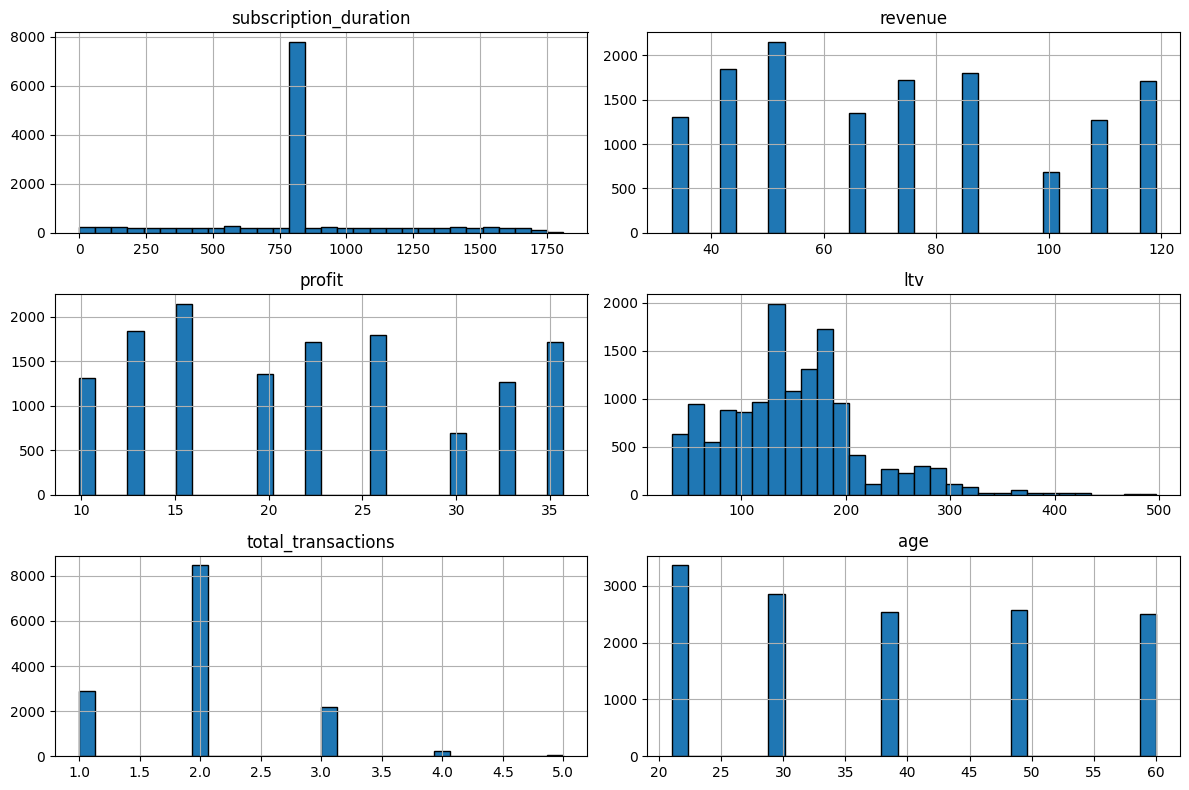

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical and categorical columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[numerical_cols].hist(figsize=(12, 8), bins=30, edgecolor='black')
plt.tight_layout()
plt.show()



In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13837 entries, 0 to 13836
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            13837 non-null  object 
 1   transaction_type       13837 non-null  object 
 2   transaction_date       13837 non-null  object 
 3   subscription_type      13837 non-null  object 
 4   customer_gender        13837 non-null  object 
 5   customer_country       13837 non-null  object 
 6   referral_type          13837 non-null  object 
 7   product                13837 non-null  object 
 8   subscription_duration  13837 non-null  float64
 9   revenue                13837 non-null  int64  
 10  profit                 13837 non-null  float64
 11  ltv                    13837 non-null  int64  
 12  total_transactions     13837 non-null  int64  
 13  is_returning_customer  13837 non-null  bool   
 14  churn_status           13837 non-null  bool   
 15  ag

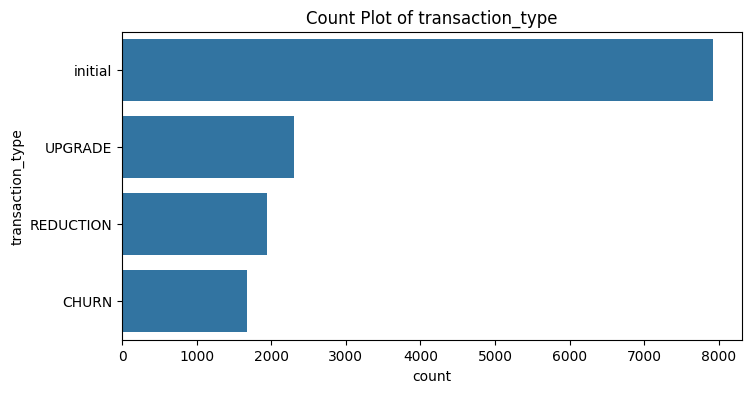

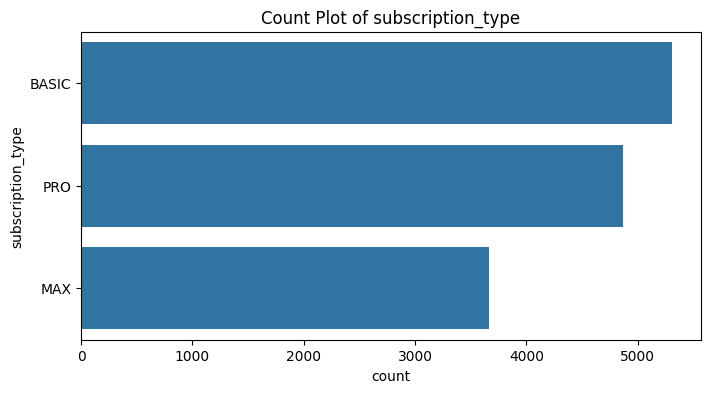

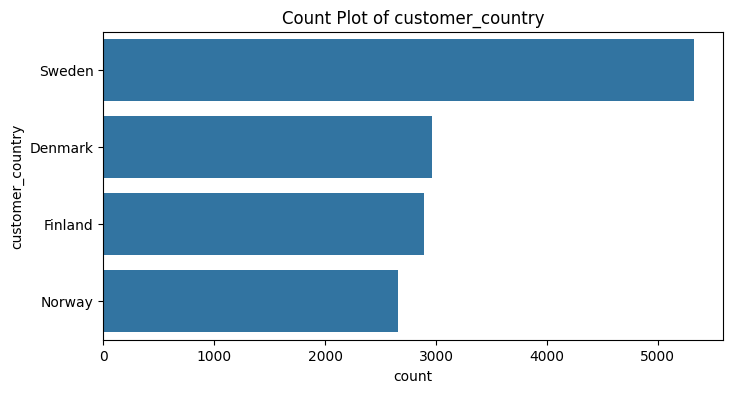

In [55]:
# Select specific categorical columns for visualization
selected_categorical_cols = ['transaction_type', 'subscription_type', 'customer_country']
for col in selected_categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=data[col], order=data[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.show()


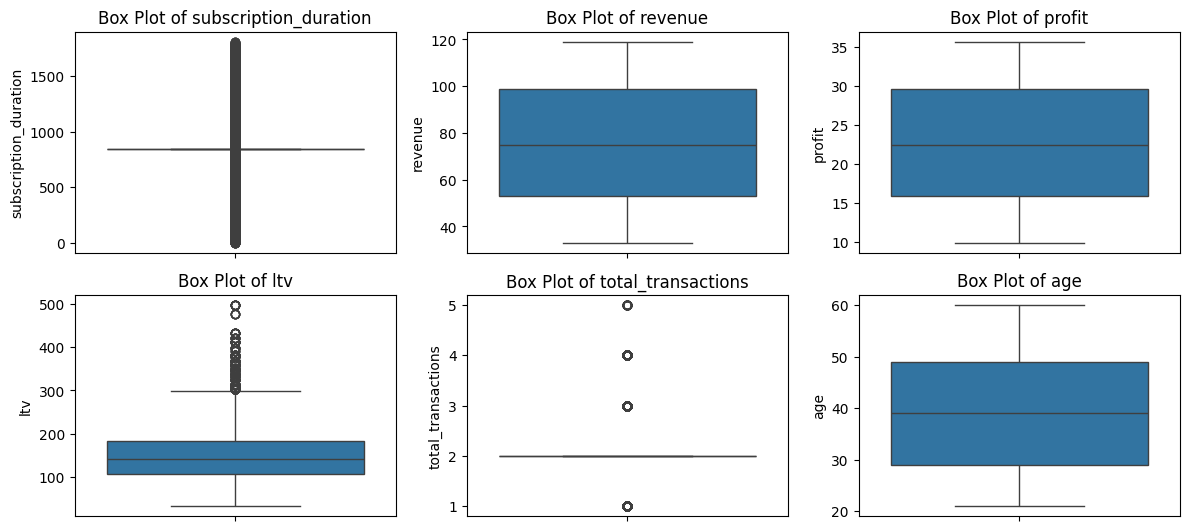

In [56]:
#check for outliers
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=data[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()


In [57]:
# Define function to detect outliers
def detect_extreme_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        mild_lower = Q1 - 1.5 * IQR
        mild_upper = Q3 + 1.5 * IQR
        extreme_lower = Q1 - 3 * IQR
        extreme_upper = Q3 + 3 * IQR

        mild_outliers = df[(df[col] < mild_lower) | (df[col] > mild_upper)]
        extreme_outliers = df[(df[col] < extreme_lower) | (df[col] > extreme_upper)]

        print(f"Column: {col}")
        print(f" Mild Outliers: {len(mild_outliers)}")
        print(f" Extreme Outliers: {len(extreme_outliers)}")
        print("-" * 40)

# Call function for numerical columns
detect_extreme_outliers(data, numerical_cols)



Column: subscription_duration
 Mild Outliers: 6280
 Extreme Outliers: 6280
----------------------------------------
Column: revenue
 Mild Outliers: 0
 Extreme Outliers: 0
----------------------------------------
Column: profit
 Mild Outliers: 0
 Extreme Outliers: 0
----------------------------------------
Column: ltv
 Mild Outliers: 361
 Extreme Outliers: 33
----------------------------------------
Column: total_transactions
 Mild Outliers: 5371
 Extreme Outliers: 5371
----------------------------------------
Column: age
 Mild Outliers: 0
 Extreme Outliers: 0
----------------------------------------


In [58]:
data.head()

,customer_id,transaction_type,transaction_date,subscription_type,customer_gender,customer_country,referral_type,product,subscription_duration,revenue,profit,ltv,total_transactions,is_returning_customer,churn_status,age,status
0,C2448,initial,2020-05-01,BASIC,Male,Norway,facebook,prd_1,844.5,33,9.9,33,1,False,False,29,Inactive
1,C2449,initial,2020-08-01,BASIC,Male,Finland,Google Ads,prd_1,1707.0,33,9.9,183,3,True,True,49,Active
2,C2449,UPGRADE,2021-07-01,PRO,Male,Finland,Google Ads,prd_1,1707.0,75,22.5,183,3,True,True,49,Active
3,C2449,CHURN,2021-10-01,PRO,Male,Finland,Google Ads,prd_1,1707.0,75,22.5,183,3,True,True,49,Active
4,C2450,initial,2020-09-01,PRO,Male,Denmark,Organic Search,prd_1,742.0,65,19.5,174,2,True,True,60,Active


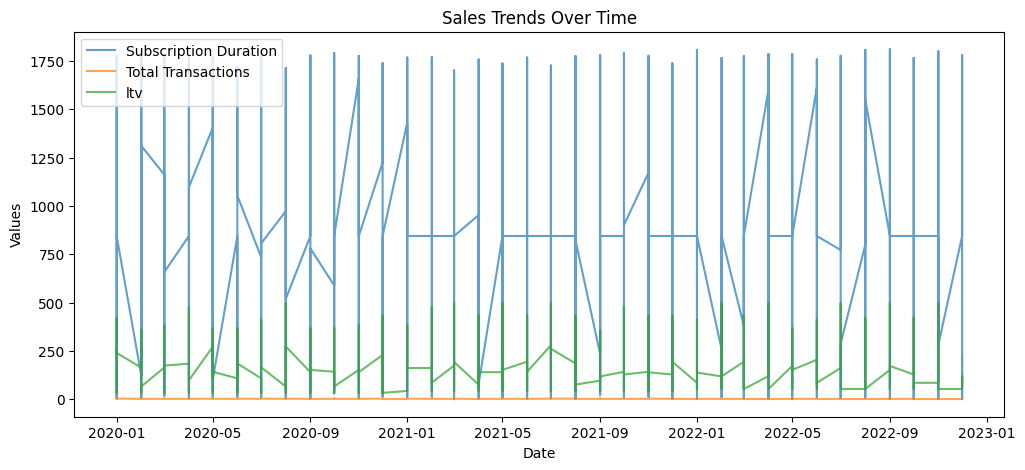

In [59]:
import matplotlib.pyplot as plt

# Convert transaction_date to datetime if not already
data['transaction_date'] = pd.to_datetime(data['transaction_date'])

# Sort by date
data = data.sort_values(by='transaction_date')

# Plot key metrics over time
plt.figure(figsize=(12, 5))
plt.plot(data['transaction_date'], data['subscription_duration'], label='Subscription Duration', alpha=0.7)
plt.plot(data['transaction_date'], data['total_transactions'], label='Total Transactions', alpha=0.7)
plt.plot(data['transaction_date'], data['ltv'], label='ltv', alpha=0.7)
plt.legend()
plt.title("Sales Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Values")
plt.show()

In [60]:
import numpy as np

def cap_outliers(df, columns, threshold=1.5):  # Lower threshold if needed
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        # Apply capping
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

# Apply capping again with a lower threshold
columns_to_cap = ['ltv']
data = cap_outliers(data, columns_to_cap, threshold=1.5)

# Re-check outliers
detect_extreme_outliers(data, columns_to_cap)

Column: ltv
 Mild Outliers: 0
 Extreme Outliers: 0
----------------------------------------


In [61]:
import pandas as pd
import numpy as np

# Select numerical columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Check skewness
skewness_values = data[numerical_cols].skew()
print("Skewness:\n", skewness_values)


Skewness:
 subscription_duration    0.104378
revenue                  0.256591
profit                   0.256591
ltv                      0.415670
total_transactions       0.567530
age                      0.251141
dtype: float64


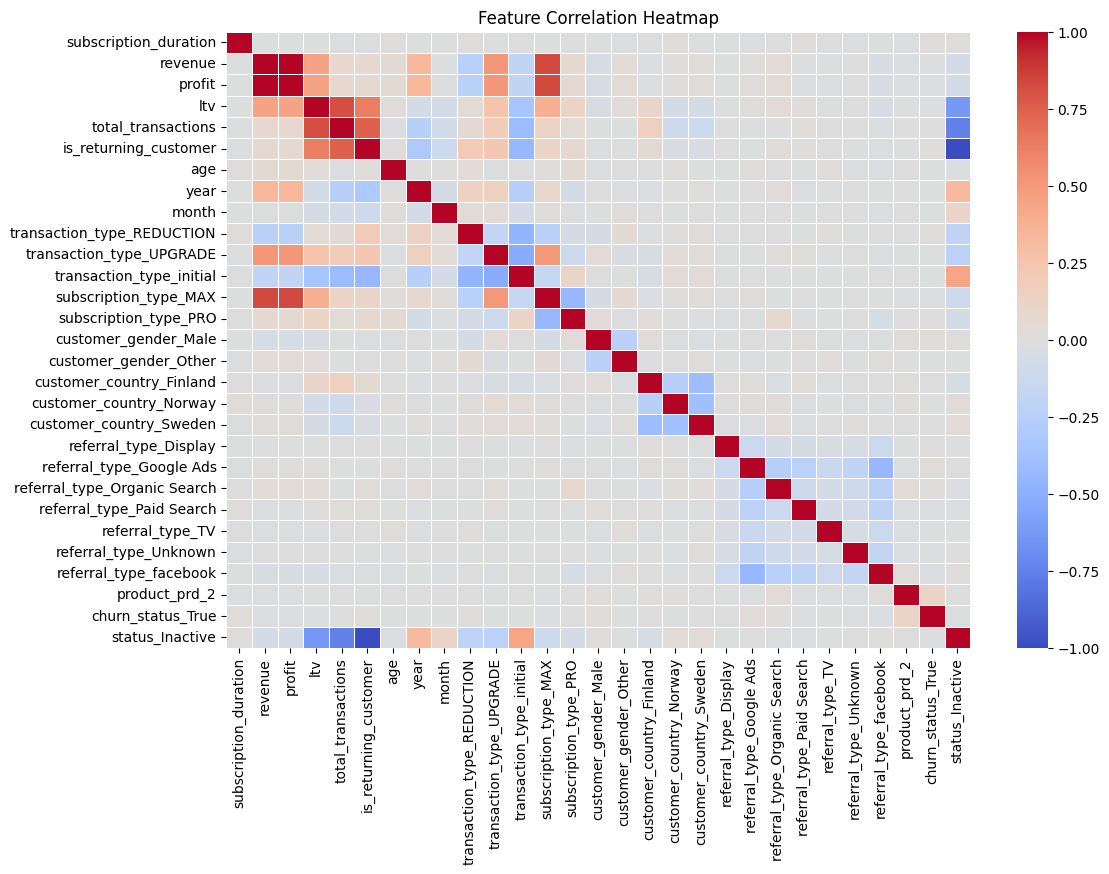


Top Correlated Features with Revenue:
 profit                          1.000000
revenue                         1.000000
subscription_type_MAX           0.829000
transaction_type_UPGRADE        0.514048
ltv                             0.448670
year                            0.334793
total_transactions              0.083674
is_returning_customer           0.068624
subscription_type_PRO           0.066075
age                             0.049151
referral_type_Organic Search    0.043380
customer_gender_Other           0.043016
customer_country_Sweden         0.019171
referral_type_Google Ads        0.013458
customer_country_Norway         0.012815
referral_type_Unknown           0.006713
subscription_duration          -0.002695
referral_type_Display          -0.004838
referral_type_Paid Search      -0.008808
month                          -0.009138
referral_type_TV               -0.009729
product_prd_2                  -0.009865
churn_status_True              -0.014326
customer_country_

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_path = "/content/updated_dataset.csv"
data = pd.read_csv(file_path, parse_dates=['transaction_date'])

# Extract date-based features
data['year'] = data['transaction_date'].dt.year
data['month'] = data['transaction_date'].dt.month
data.drop(columns=['transaction_date'], inplace=True)

# Convert categorical columns into numerical using One-Hot Encoding
categorical_cols = ['transaction_type', 'subscription_type', 'customer_gender',
                    'customer_country', 'referral_type', 'product', 'churn_status','status']

data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
customer_ids = data[['customer_id']]
data_numeric = data.drop(columns=['customer_id'])

# Compute correlation matrix
correlation_matrix = data_numeric.corr()

# Visualize correlation using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Identify highly correlated features with 'revenue'
correlated_features = correlation_matrix['revenue'].sort_values(ascending=False)
print("\nTop Correlated Features with Revenue:\n", correlated_features)

# Add 'customer_id' back after correlation analysis
data = pd.concat([customer_ids, data_numeric], axis=1)


In [63]:
import pandas as pd
import numpy as np

# Assign df to random_data to use df as the base for dummy data
random_data = data.copy()

# Select a random sample of existing data
dummy_data = random_data.sample(n=1000, replace=True).reset_index(drop=True)  # Increased to 2000 rows

# Modify some values to make them unique
dummy_data["transaction_id"] = range(len(random_data) + 1, len(random_data) + len(dummy_data) + 1)
dummy_data["transaction_date"] = pd.date_range(start="2023-01-01", periods=len(dummy_data), freq="D")

# Ensure 18 columns exist
required_columns = ["transaction_type", "transaction_date", "subscription_type", "customer_id",  "customer_gender", "age", "customer_country", "referral_type", "product", "subscription_duration", "revenue", "profit", "ltv", "total_transactions", "is_returning_customer", "churn_status", "status"]

for col in required_columns:
    if col not in dummy_data.columns:
        if col in ["customer_id", "total_transactions"]:
            dummy_data[col] = np.random.randint(1, 10000, size=len(dummy_data))
        elif col in [ "revenue", "profit", "ltv"]:
            dummy_data[col] = np.random.uniform(10, 1000, size=len(dummy_data))
        elif col == "customer_gender":
            dummy_data[col] = np.random.choice(["Male", "Female", "Other"], size=len(dummy_data))
        elif col == "age":
            dummy_data[col] = np.random.randint(18, 65, size=len(dummy_data))
        elif col == "customer_country":
            dummy_data[col] = np.random.choice(["USA", "UK", "India", "Canada", "Germany"], size=len(dummy_data))
        elif col == "referral_type":
            dummy_data[col] = np.random.choice(["Friend", "Ad Campaign", "Organic", "Social Media"], size=len(dummy_data))
        elif col == "product":
            dummy_data[col] = np.random.choice(["Basic Plan", "Premium Plan", "Enterprise Plan"], size=len(dummy_data))
        elif col == "subscription_duration":
            dummy_data[col] = np.random.choice(["1 Month", "6 Months", "12 Months"], size=len(dummy_data))
        elif col == "is_returning_customer":
            dummy_data[col] = np.random.choice([True, False], size=len(dummy_data))
        elif col == "churn_status":
            dummy_data[col] = np.random.choice(["Active", "Churned"], size=len(dummy_data))
        elif col == "status":
            dummy_data[col] = np.random.choice(["Active", "Inactive"], size=len(dummy_data))

# Append dummy data to the dataset
random_data = pd.concat([random_data, dummy_data], ignore_index=True)

# Display last few rows
print(random_data.tail())

      customer_id  subscription_duration  revenue  profit    ltv  \
14832       C3389                  844.5       53    15.9  138.0   
14833       C9901                 1278.0       53    15.9   53.0   
14834       C5563                  844.5      119    35.7  298.0   
14835       C8507                    2.0       53    15.9   53.0   
14836       C8202                  844.5      119    35.7  228.0   

       total_transactions  is_returning_customer  age  year  month  ...  \
14832                   2                   True   29  2022     10  ...   
14833                   1                  False   21  2022      3  ...   
14834                   4                   True   21  2022      9  ...   
14835                   1                  False   21  2022      4  ...   
14836                   2                   True   39  2022      4  ...   

       churn_status_True  status_Inactive  transaction_id  transaction_date  \
14832              False            False         14833.0    

In [64]:
data.to_csv('updated_dataset.csv', index=False)


In [65]:
data.head(5)

,customer_id,subscription_duration,revenue,profit,ltv,total_transactions,is_returning_customer,age,year,month,...,referral_type_Display,referral_type_Google Ads,referral_type_Organic Search,referral_type_Paid Search,referral_type_TV,referral_type_Unknown,referral_type_facebook,product_prd_2,churn_status_True,status_Inactive
0,C5350,844.5,99,29.7,259.0,3,True,39,2020,1,...,False,False,False,False,False,False,True,True,False,False
1,C5398,844.5,65,19.5,130.0,2,True,60,2020,1,...,False,False,False,False,False,True,False,False,False,False
2,C5420,1486.0,99,29.7,239.0,3,True,39,2020,1,...,False,True,False,False,False,False,False,False,True,False
3,C5433,1663.0,99,29.7,175.0,3,True,49,2020,1,...,False,False,False,False,False,False,True,False,True,False
4,C5440,844.5,99,29.7,174.0,2,True,21,2020,1,...,False,False,False,False,False,False,True,True,False,False
